# 03 · Fine-tuning del clasificador de tipo de lugar

Entrena un clasificador multiclase sobre el corpus turístico. La tarea elegida es predecir `tipo_lugar`, coherente con la personalidad de TicoGuía y con el filtro del RAG.

Instalar una vez desde la raíz: `pip install -r requirements.txt`. Para acelerar el entrenamiento se recomienda Colab con GPU T4; el resto del proyecto corre localmente.

In [1]:
import json
import random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, Trainer, TrainingArguments, pipeline)
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
RUTA_PROYECTO = Path.cwd().resolve()
if not (RUTA_PROYECTO / 'data').is_dir(): RUTA_PROYECTO = RUTA_PROYECTO.parent
RUTA_CORPUS = RUTA_PROYECTO / 'data' / 'corpus_resenas.csv'
RUTA_MODELO = RUTA_PROYECTO / 'models' / 'clasificador_tipo_lugar'
RUTA_RESULTADOS = RUTA_PROYECTO / 'resultados'
MODELO_BASE = 'dccuchile/distilbert-base-spanish-uncased'
df = pd.read_csv(RUTA_CORPUS).dropna(subset=['texto', 'tipo_lugar']).copy()
df['texto'] = df['texto'].astype(str)
assert len(df) >= 3000, 'El proyecto exige al menos 3,000 reseñas etiquetadas.'
print(f'{len(df):,} reseñas etiquetadas | {df.tipo_lugar.nunique()} clases')

C:\Proyecto3_Chatbot_Turístico_Inteligente\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


5,018 reseñas etiquetadas | 7 clases


## División reproducible 70/15/15

La división es estratificada para preservar la proporción de categorías y evita que las métricas de test influyan durante el entrenamiento.

In [2]:
etiquetas = sorted(df['tipo_lugar'].unique())
label2id = {etiqueta: i for i, etiqueta in enumerate(etiquetas)}
id2label = {i: etiqueta for etiqueta, i in label2id.items()}
df['label'] = df['tipo_lugar'].map(label2id)
train_df, temporal_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
valid_df, test_df = train_test_split(temporal_df, test_size=0.50, stratify=temporal_df['label'], random_state=SEED)
for nombre, particion in [('train', train_df), ('validation', valid_df), ('test', test_df)]:
    print(f'{nombre:10}: {len(particion):4} ({len(particion)/len(df):.1%})')
assert len(train_df) + len(valid_df) + len(test_df) == len(df)

train     : 3512 (70.0%)
validation:  753 (15.0%)
test      :  753 (15.0%)


## Baseline zero-shot

Este baseline no usa las etiquetas del entrenamiento. Por costo computacional se evalúa una muestra estratificada fija de test; el modelo fine-tuneado sí se evalúa sobre todo el conjunto de test.

In [3]:
MODELO_ZERO_SHOT = 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'
N_BASELINE = min(300, len(test_df))
muestra_baseline = test_df.groupby('tipo_lugar', group_keys=False).apply(lambda x: x.sample(max(1, round(N_BASELINE * len(x) / len(test_df))), random_state=SEED)).head(N_BASELINE)
clasificador_zero_shot = pipeline('zero-shot-classification', model=MODELO_ZERO_SHOT, device=0 if torch.cuda.is_available() else -1)
nombres_candidatos = [etiqueta.replace('_', ' ') for etiqueta in etiquetas]
pred_zero_shot = []
for texto in muestra_baseline['texto']:
    salida = clasificador_zero_shot(texto[:512], candidate_labels=nombres_candidatos, hypothesis_template='Esta reseña es sobre {}.')
    pred_zero_shot.append(label2id[salida['labels'][0].replace(' ', '_')])
metricas_zero_shot = {'n_test': len(muestra_baseline), 'accuracy': accuracy_score(muestra_baseline['label'], pred_zero_shot), 'f1_macro': f1_score(muestra_baseline['label'], pred_zero_shot, average='macro', zero_division=0)}
metricas_zero_shot

{'n_test': 300, 'accuracy': 0.6266666666666667, 'f1_macro': 0.519770050180606}

## Fine-tuning

Se usa DistilBETO y un máximo de tres épocas, como solicita el proyecto.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODELO_BASE)
def a_dataset(frame):
    dataset = Dataset.from_pandas(frame[['texto', 'label']], preserve_index=False)
    return dataset.map(lambda lote: tokenizer(lote['texto'], truncation=True, max_length=256), batched=True)

ds_train, ds_valid, ds_test = map(a_dataset, [train_df, valid_df, test_df])
modelo = AutoModelForSequenceClassification.from_pretrained(MODELO_BASE, num_labels=len(etiquetas), label2id=label2id, id2label=id2label)

def calcular_metricas(eval_pred):
    logits, labels = eval_pred
    predicciones = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predicciones, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(labels, predicciones), 'f1_macro': f1, 'precision_macro': precision, 'recall_macro': recall}

argumentos = TrainingArguments(output_dir=str(RUTA_RESULTADOS / 'trainer'), num_train_epochs=3, per_device_train_batch_size=8, per_device_eval_batch_size=16, learning_rate=2e-5, weight_decay=0.01, evaluation_strategy='epoch', save_strategy='epoch', load_best_model_at_end=True, metric_for_best_model='f1_macro', seed=SEED, report_to='none')
trainer = Trainer(model=modelo, args=argumentos, train_dataset=ds_train, eval_dataset=ds_valid, tokenizer=tokenizer, data_collator=DataCollatorWithPadding(tokenizer=tokenizer), compute_metrics=calcular_metricas)
trainer.train()

Map: 100%|██████████| 753/753 [00:00<00:00, 2679.89 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at dccuchile/distilbert-base-spanish-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Proyecto3_Chatbot_Turístico_Inteligente\.venv\Lib\site-packages\transformers\training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\victo\AppData\Local\Temp\ipykernel_38332\3367223962.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=modelo, args=argumentos, train_dataset=ds_train, eval_dataset=ds_valid, tokenizer=t

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,No log,0.730728,0.776892,0.674327,0.830985,0.663953
2,1.006000,0.657608,0.804781,0.754678,0.780342,0.741892
3,0.549600,0.647131,0.804781,0.760680,0.777234,0.750123


C:\Proyecto3_Chatbot_Turístico_Inteligente\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Proyecto3_Chatbot_Turístico_Inteligente\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Proyecto3_Chatbot_Turístico_Inteligente\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=1317, training_loss=0.6888932884870919, metrics={'train_runtime': 2853.3584, 'train_samples_per_second': 3.692, 'train_steps_per_second': 0.462, 'total_flos': 389302579968480.0, 'train_loss': 0.6888932884870919, 'epoch': 3.0})

## Evaluación y guardado

Las métricas finales se calculan una única vez sobre test. El archivo JSON se integrará después con las conversaciones del notebook 04.

C:\Proyecto3_Chatbot_Turístico_Inteligente\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


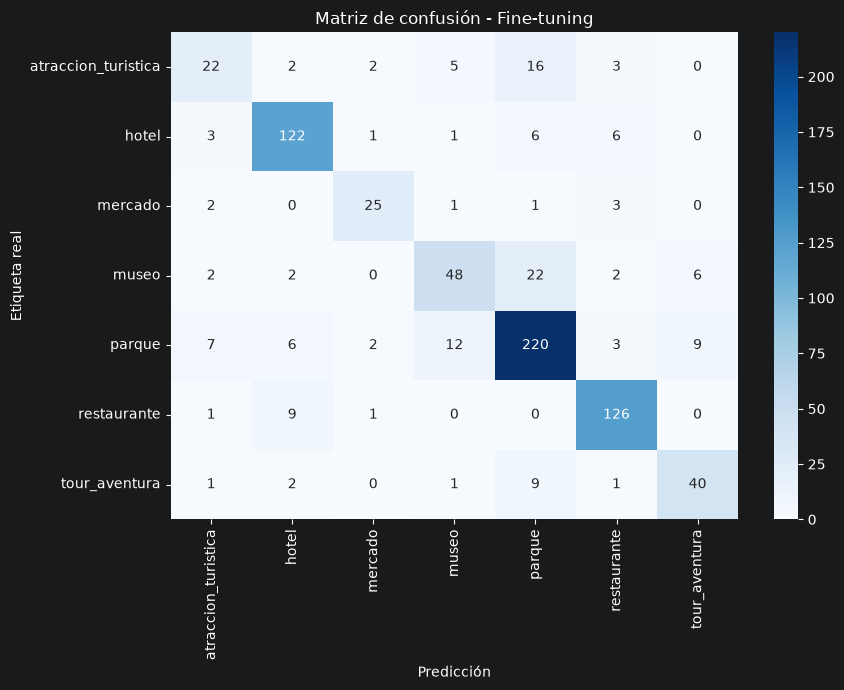

                     precision    recall  f1-score   support

atraccion_turistica       0.58      0.44      0.50        50
              hotel       0.85      0.88      0.87       139
            mercado       0.81      0.78      0.79        32
              museo       0.71      0.59      0.64        82
             parque       0.80      0.85      0.83       259
        restaurante       0.88      0.92      0.90       137
      tour_aventura       0.73      0.74      0.73        54

           accuracy                           0.80       753
          macro avg       0.76      0.74      0.75       753
       weighted avg       0.79      0.80      0.80       753



{'tarea': 'clasificación de tipo_lugar',
 'modelo_base': 'dccuchile/distilbert-base-spanish-uncased',
 'seed': 42,
 'split': {'train': 3512, 'validation': 753, 'test': 753},
 'zero_shot': {'n_test': 300,
  'accuracy': 0.6266666666666667,
  'f1_macro': 0.519770050180606},
 'fine_tuning_test': {'accuracy': 0.8007968127490039,
  'f1_macro': 0.7507367250316667,
  'precision_macro': 0.7642315175306047,
  'recall_macro': 0.7420261878205466},
 'etiquetas': ['atraccion_turistica',
  'hotel',
  'mercado',
  'museo',
  'parque',
  'restaurante',
  'tour_aventura']}

In [5]:
prediccion_test = trainer.predict(ds_test)
pred_test = np.argmax(prediccion_test.predictions, axis=-1)
metricas_finetuning = calcular_metricas((prediccion_test.predictions, test_df['label'].to_numpy()))
matriz = confusion_matrix(test_df['label'], pred_test, labels=list(range(len(etiquetas))))
plt.figure(figsize=(9, 7))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=etiquetas, yticklabels=etiquetas)
plt.xlabel('Predicción'); plt.ylabel('Etiqueta real'); plt.title('Matriz de confusión - Fine-tuning'); plt.tight_layout(); plt.show()
print(classification_report(test_df['label'], pred_test, target_names=etiquetas, zero_division=0))
RUTA_MODELO.mkdir(parents=True, exist_ok=True); RUTA_RESULTADOS.mkdir(exist_ok=True)
trainer.save_model(RUTA_MODELO); tokenizer.save_pretrained(RUTA_MODELO)
metricas = {'tarea': 'clasificación de tipo_lugar', 'modelo_base': MODELO_BASE, 'seed': SEED, 'split': {'train': len(train_df), 'validation': len(valid_df), 'test': len(test_df)}, 'zero_shot': metricas_zero_shot, 'fine_tuning_test': metricas_finetuning, 'etiquetas': etiquetas}
(RUTA_RESULTADOS / 'metricas_clasificador.json').write_text(json.dumps(metricas, ensure_ascii=False, indent=2), encoding='utf-8')
metricas